In [1]:
# Analysis: Retail Store Sales (cleaned)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_raw = pd.read_csv("../data/raw/retail_store_sales.csv")
df = pd.read_parquet("../data/processed/clean_cli.parquet")

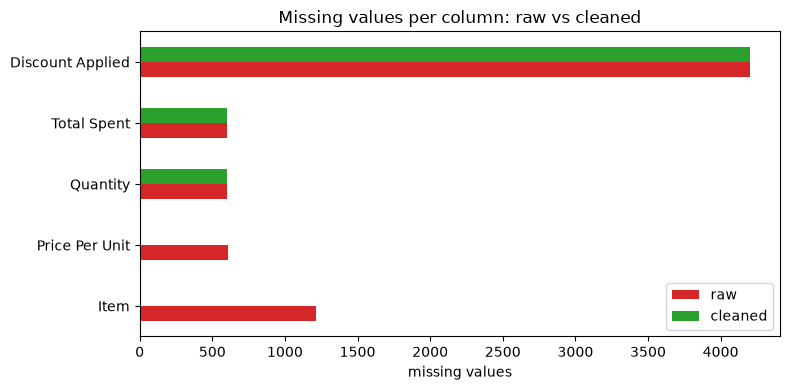

In [3]:
missing = pd.DataFrame({
    "raw": df_raw.isna().sum(),
    "cleaned": df.isna().sum(),
})
missing = missing[missing["raw"] > 0]

ax = missing.plot.barh(figsize=(8, 4), color=["#d62728", "#2ca02c"])
ax.set_title("Missing values per column: raw vs cleaned")
ax.set_xlabel("missing values")
plt.tight_layout()
plt.savefig("../data/processed/missingness_before_after.png", dpi=150)
plt.show()

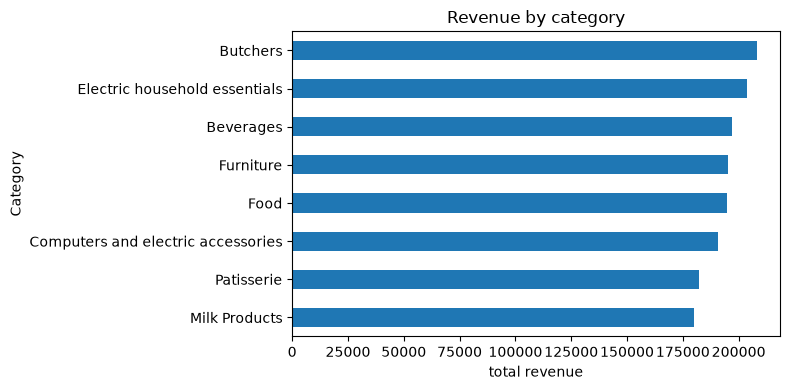

In [4]:
ax = (df.groupby("Category")["Total Spent"].sum()
        .sort_values()
        .plot.barh(figsize=(8, 4), title="Revenue by category"))
ax.set_xlabel("total revenue")
plt.tight_layout()
plt.show()

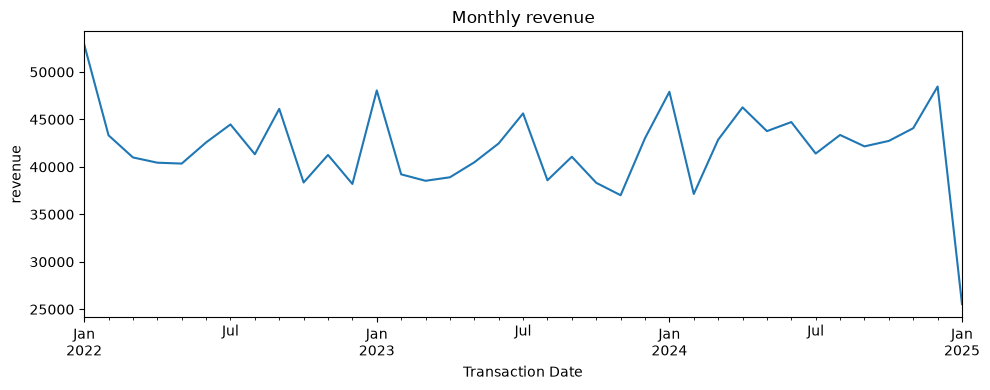

In [5]:
monthly = df.set_index("Transaction Date").resample("ME")["Total Spent"].sum()
ax = monthly.plot(figsize=(10, 4), title="Monthly revenue")
ax.set_ylabel("revenue")
plt.tight_layout()
plt.show()

time analysis was impossible on the raw data; dates were strings

## Findings

- **Revenue is stable across the full period:** monthly revenue oscillates
  between roughly 37k and 48k from 2022 through 2024, with no growth trend
  and no clear seasonality — consistent with synthetically generated data.

- **The apparent crash in January 2025 is an artifact,** not a real drop:
  the final month is only partially covered by the dataset. Partial trailing
  periods are a classic time-series pitfall.

- **Revenue is spread almost evenly across categories:** Butchers leads
  (~200k) and Milk Products trails (~180k) — a spread of only about 10%,
  with no dominant or weak category.

- **What the cleaning enabled:** time-based analysis was impossible on the
  raw data (dates were stored as strings), and revenue totals would have
  silently ignored ~600 missing values. After recovery, all 12,575
  transactions carry a price and an item label.